# Introduction to EDA

## Univariate stats 
(ความสัมพันธ์ของตัวแปรเดียว)

In [1]:
import pandas as pd
df = pd.read_csv('http://www.ishelp.info/data/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [3]:
df.shape

(1338, 7)

count for row in each column

In [9]:
for col in df.columns:
    print(f'{col}: {df[col].count()}')

age: 1338
sex: 1338
bmi: 1338
children: 1338
smoker: 1338
region: 1338
charges: 1338


check unique value

In [10]:
# useful for categorical data
for col in df.columns:
    print(f'{col}: {df[col].nunique()}')

age: 47
sex: 2
bmi: 548
children: 6
smoker: 2
region: 4
charges: 1337


check type of data

In [19]:
# check type of data and check whether data is numeric or not
for col in df.columns:
    print(f'{col}:\n {df[col].dtype}\n isNumeric: {pd.api.types.is_numeric_dtype(df[col])}')

age:
 int64
 isNumeric: True
sex:
 object
 isNumeric: False
bmi:
 float64
 isNumeric: True
children:
 int64
 isNumeric: True
smoker:
 object
 isNumeric: False
region:
 object
 isNumeric: False
charges:
 float64
 isNumeric: True


check missing value

In [20]:
for col in df.columns:
    print(f'{col}: {df[col].isnull().sum()}')

age: 0
sex: 0
bmi: 0
children: 0
smoker: 0
region: 0
charges: 0


boundary and middle of data

In [ ]:
import numpy as np
print(f'count: {df.charges.count()}')
print(f'min: {df.charges.min()}')
print(f'Q1: {df.charges.quantile(.25)}') # inner quartile
print(f'Q2: {df.charges.quantile(.50)}') # median
print(f'Q3: {df.charges.quantile(.75)}') # outer quartile
print(f'max: {df.charges.max()}')
print(f'mean: {df.charges.mean()}')
print(f'median: {df.charges.median()}')
print(f'mode: {df.charges.mode()[0]}') # value that appear the most (ฐานนิยม) | return data and index

count: 1338
min: 1121.8739
Q1: 4740.28715
Q2: 9382.033
Q3: 16639.912515
max: 63770.42801
mean: 13270.422265141257
median: 9382.033
mode: 1639.5631


Standard deviation

- use to view how our data spread out

In [29]:
sample_std = df['charges'].std() 
print(f'sample_std: {sample_std}')
# numpy use population normal distribution by default
population_std = np.std(df['charges']) 
print(f'population_std: {population_std}')
# to use sample normal distribution
np_sample_std = np.std(df['charges'], ddof=1) 
print(f'np sample_std: {population_std}')

sample_std: 12110.011236694001
population_std: 12105.484975561612
np sample_std: 12105.484975561612


(Ab)Normality: Kurt

> Skew

- view whether our data have Skewness (extremely frequency of value is in either side of data)
    - Right skew: data tends to pile in left side of graph (x-axis) (below 50% of data) (we will watch which type of skew based on direction of long tail) will have "positive skewness "score
    - Left skew: data tends to pile in right side of graph (greater than 50% of data) will have negative "positive skewness" score
- will have range of acceptance skew (-score(e.g. -1) < x < score(e.g. 1)) and can mathematically adjust to suit for bell shape std later (because in most of statistic will assume data is in bell shape distribution)

In [36]:
from scipy.stats import skew
print(f'skewness score: {skew(df.charges, bias = False)}')
# in other method
print(f'df skewness score: {df.charges.skew()}')

skewness score: 1.5158796580240383
df skewness score: 1.5158796580240388


> Kurt

- whether bell shape (peak of data) have 
    - too high (positive kurtosis score)
        data is cluster close together (กระจุก) in center not enough spread out to the tail
    - match bell shape(kurtosis score equal to zero)
    - too low (negative kurtosis score) shape
        data is spread out. So, peak of data is short

In [37]:
from scipy.stats import kurtosis
print(f'kurtosis score: {kurtosis(df.charges, bias = False)}')
# in other method
print(f'df kurtosis score: {df.charges.kurtosis()}')

kurtosis score: 1.6062986532967916
df kurtosis score: 1.6062986532967907


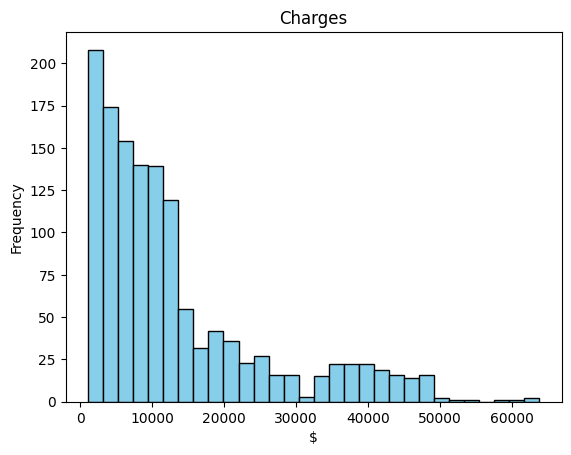

In [38]:
import matplotlib.pyplot as plt
import numpy as np
# plotting graph
plt.hist(df.charges, bins=30, color='skyblue', edgecolor='black')
# labels and title
plt.xlabel('$')
plt.ylabel('Frequency')
plt.title('Charges')

# Display the plot
plt.show()

## Bivariate stats
(ความสัมพันธ์ระหว่างสองตัวแปร)

### number to number relationship

- independent variable: feature
- dependent variable  : label
So, the bivariate stats is the relationship between each feature with label

effect size
    refer to the relationship with the label — or the amount of the effect that each feature has on label measured separately

Correlation

    use for test effect size between numeric label and numeric feature can visualize by scatter plot

- assume each data is normally distributed (Gaussian distribution) 
- direction of line can tell by using sign(positive or negative):
    - if correlation score have positive value, when feature increase label is increase too
    - if correlation score have negative value, when feature increase. In contrast, label is decrease
- value of correlation can tell:
    - larger value can tell feature  have large effect size on label (x > .50)
    - smaller value can tell feature have small effect size on label (.10 < x < .29)
    - medium value is in range between .30 and .49
- correlation can visualize by using intersect area between feature and label (higher intersect area higher correlation) [visualize web](https://rpsychologist.com/d3/correlation/)

> assumption

in order to validly interpreted pearson correlation, there are assumption that must met
1. Continuous data
- can become from lack of data because they maybe hidden dot in empty area
2. Linear relationship
- relationship need to be straight line (if relationship become curve. it can be demonstrate relationship with other data (3 or more relationship) and violate assumption of bivariate relationship)
**can be adjust later**
3. Homoskedastic relationship
- refer to consistency of the relationship across all type of all value of feature and label (because correlation is relationship between data across entire data)
**can be adjust later**

*if can't adjust, can use other statistic that not depends on normal distribution (e.g. non-parametric a.k.a. distribution-free). For example, Kendall's(tau) or spearman's(rho)*

p-value

- "the general purpose to statistical analysis is **hypotheses** or explore relationship among feature and label. By default, we assume there is no relationship between feature and label. Let say, age don't effect charge amount — we call this "Null hypothesis (สมมติฐานหลัก, สมมติฐานว่าง)". But if we start to see persistent trends that higher age leads to higher cost — we can reject null hypothesis." That is the role of p-value

p-value  is the probability that the result we found will not repeat in future data collection or the likelihood that what we saw is not truly represent the overall population — can be mean as the result we found come from coincidence in case of null hypothesis is real. 

- if p-value is lower — it represent that the result we found will present again in future data collection. So, we can trust result 
    - p < 0.05
        - represent less than 5% that result come from coincidence (called statistical significant) also can found Type 1 error (False positive - assumed significant but actually not)
    - p < 0.01 
        - is strong evidence to null hypothesis can decrease Type 1 error but also
        can lead to Type 2 error (False negative - cause disregard some important result)
- if p-value is higher - result can come from coincidence. So, can not reject null hypothesis

p-value limitation
- can't measure effect size (can be use with Cohen's d or Odds Ratio) 
- may have statistically impact but not significantly practical impact 
- p-value determined by
    - sample size (frequency of occurrence)
        Conceptually, future can predict by past. 
        - more dataset suggest correlation we found likely actually represent population. but small effect can cause lower p-value and seem like statistically significant
        - less dataset can not measure significant even if have high impact to data (if collect more data p-value may increase or decrease)
        *higher dataset can leads to lower p-value*
    - possible outcome (degree of freedom; DoF)
        *higher DoF tends to increase p-value* 



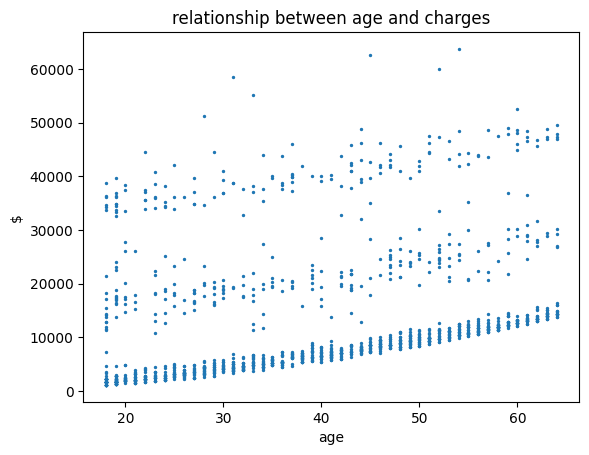

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# plotting graph
plt.scatter(df.age, df.charges, s=2.0)
# labels and title
plt.xlabel('age')
plt.ylabel('$')
plt.title('relationship between age and charges')

# Display the plot
plt.show()

ANOVA

    use for test effect size between numeric label and categorical feature can visualize by Bar chart    

Chi-square

    use for test effect size between categorical label and categorical feature can visualize by CrossTab (table with relationship between each feature and label)